## 3.1例子

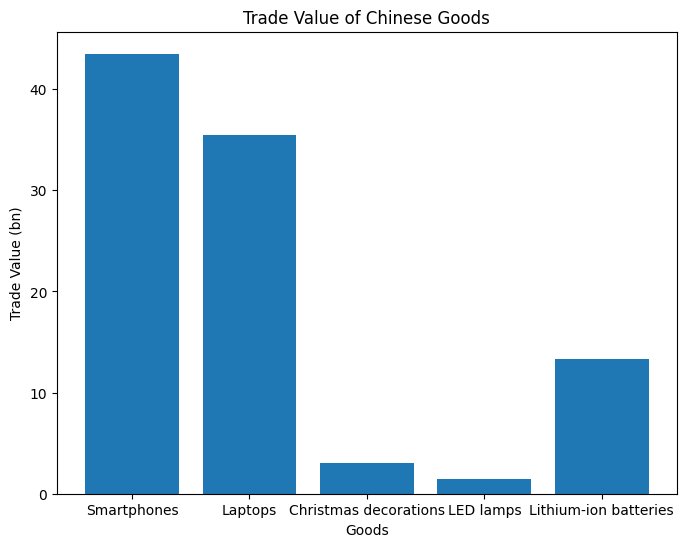

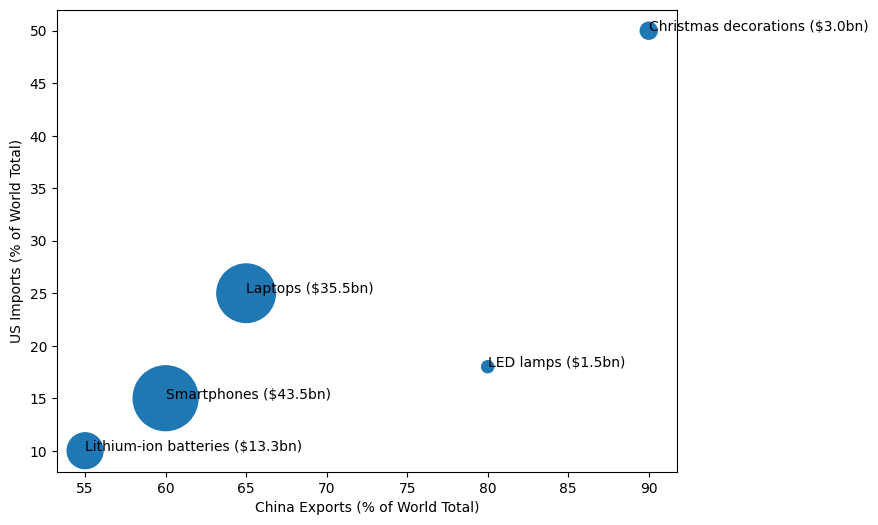

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
# 设置工作目录
work_dir = r"D:\jjdsjyrgzn_python\3shangjike"
os.chdir(work_dir)
# 导入数据
data = pd.read_excel("trade_data.xlsx")
# 数据解析：提取各列数据
x_vals = data["China_exports_in_world_%"]
y_vals = data["US_imports_in_world_%"]
values = data["Trade_value_from_China_to_US_bn"]
names = data["Name"]
# 绘制柱状图
plt.figure(figsize=(8, 6))
plt.bar(names , values)
plt.title("Trade Value of Chinese Goods")
plt.xlabel("Goods")
plt.ylabel("Trade Value (bn)")
plt.show()
# 绘制散点图
plt.figure(figsize=(8, 6))
plt.scatter(x_vals , y_vals , s=values * 50) # 气泡大小与贸易额成比例
for i in range(len(names)):
    plt.annotate(f"{names.iloc[i]} (${values.iloc[i]}bn)", (x_vals.iloc[i], y_vals.iloc[i]))
plt.xlabel("China Exports (% of World Total)")
plt.ylabel("US Imports (% of World Total)")
plt.show()

## 3.2知识点拆解
### 导入模块
os：Operating System（操作系统）的缩写。提供与操作系统交互的功能，用于管理文件和目录，比如新建文件夹、删除文件、获取当前工作路径、遍历文件夹里的所有图片等。  
pandas：源于Panel Data和Statistics。强大的数据分析库，可以处理结构化数据（如最核心功能是表格数据）  
matplotlib.pyplot：mat: 取自 MATLAB、plot、Library。绘图库，用于生成各种可视化图表
### 设置工作目录
通过 os.chdir() ，change directory的缩写，设置工作目录，确保程序能够正确定位到数据文件。

### 导入数据
使用 pandas 的 read_excel() 方法可以轻松读取 Excel 文件，并将其转换为 DataFrame数据结构。在导入数据后，可以通过以下方法查看数据的大致结构：

In [3]:
data = pd.read_excel("trade_data.xlsx") 
# 查看前5行数据
print(data.head())
# 查看列名
print(data.columns)
# 查看数据的维度，输出 (行数 , 列数)
print(data.shape)

                    Name  China_exports_in_world_%  US_imports_in_world_%  \
0            Smartphones                        60                     15   
1                Laptops                        65                     25   
2  Christmas decorations                        90                     50   
3              LED lamps                        80                     18   
4  Lithium-ion batteries                        55                     10   

   Trade_value_from_China_to_US_bn  
0                             43.5  
1                             35.5  
2                              3.0  
3                              1.5  
4                             13.3  
Index(['Name', 'China_exports_in_world_%', 'US_imports_in_world_%',
       'Trade_value_from_China_to_US_bn'],
      dtype='object')
(5, 4)


取数的其他实用参数配置，以下面这段代码为例：
```
import pandas as pd
df = pd.read_excel('某一个excel.xlsx', sheet_name=0, nrows=5, usecols="A:C")
print(df.shape)
```
- sheet_name=0：代表读取 Excel 文件里的第一张工作表（Sheet1）。
- nrows=5：代表只读取前 5 行数据（通常用来快速预览一个超大的表格）。
- usecols="A:C"：代表只读取 Excel 表格里的 A 列、B 列、C 列。

### 提取列数据并画图
在 DataFrame 中，可以通过列名提取某一列的数据，返回一个 pandas.Series 对象。提取列数据的目的是为了对某些特定信息进行单独操作，比如绘图或分析。通过提取列数据，可以让代码更加简洁、清晰，同时便于后续操作和复用。

也可以直接提取某一个数字，例如data.iloc[2, 1]是提取Pandas DataFrame 中的第 3 行第 2 列数据  

散点图中s 参数控制的是点的面积,不是半径。可以设置为数组。

柱状图的横轴可以是字符串也可以是数字类别（比如年份）。
柱状图的纵轴必须是数值。

在图表中添加标注可以使数据展示更加直观，尤其是在散点图中，可以通过标注进一步解释每个点的含义。plt.annotate() 是 matplotlib 提供的一个方法，用于在图表的指定位置添加文本信息。
#### 循环部分
for i in range(len(names)):
- 使用 for 循环遍历每个数据点。
- len(names) 表示数据点的总数（即商品的数量）。
- i 是当前循环的索引，用于访问每个商品的名称、贸易额以及对应的坐标。
#### plt.annotate() 的第一个参数
f"{names.iloc[i]} (${values.iloc[i]}bn)"
- f"" 是 Python 的格式化字符串，用于动态生成标注内容。
- names.iloc[i]：获取第 i 个商品的名称。
- values.iloc[i]：获取第 i 个商品的贸易额。
- 标注内容示例："Laptops ($50bn)"，表示商品名称和对应的贸易额。
- plt.annotate() 完全可以只添加纯文本注释。
- plt.annotate() 的第一个参数总是标注文本
#### plt.annotate() 的第二个参数
(x_vals.iloc[i], y_vals.iloc[i])
- 指定标注的位置，即当前点的横坐标和纵坐标。
- x_vals.iloc[i]：获取第 i 个点的横坐标（中国出口占比）。
- y_vals.iloc[i]：获取第 i 个点的纵坐标（美国进口占比）。
#### iloc 的作用
- iloc 是 Pandas 提供的方法，用于基于整数索引（行号或列号）访问数据。
- 语法：DataFrame.iloc[row_index, column_index] 或 Series.iloc[row_index]。
- 在本例中，iloc[i] 用于通过第 i 行的索引逐行提取数据：
- names.iloc[i]：提取第 i 行的商品名称。
- x_vals.iloc[i]：提取第 i 行的横坐标值（中国出口占比）。
- y_vals.iloc[i]：提取第 i 行的纵坐标值（美国进口占比）。
- values.iloc[i]：提取第 i 行的贸易额。
- 使用 iloc 的好处是可以按行号逐行访问数据，适合循环遍历和逐点标注。

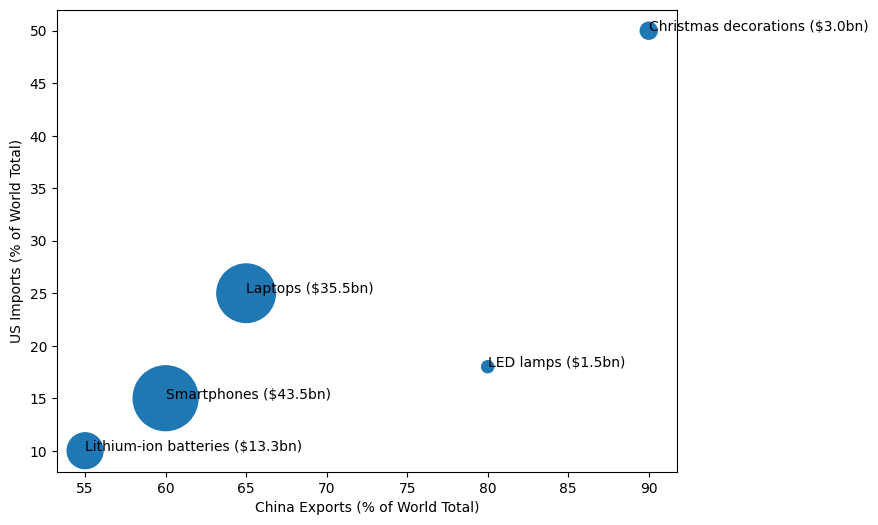

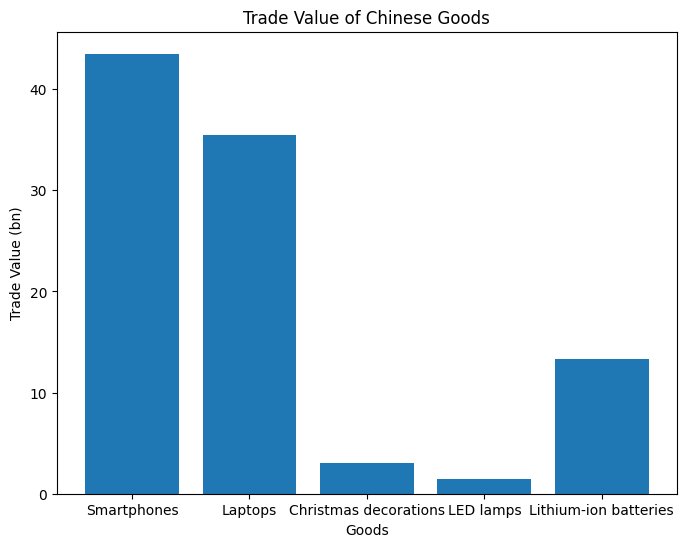

In [10]:
# 提取中国出口占比
x_vals = data["China_exports_in_world_%"]
# 提取美国进口占比
y_vals = data["US_imports_in_world_%"]
# 提取贸易额
values = data["Trade_value_from_China_to_US_bn"] 
# 提取商品名称
names = data["Name"] 
# 提取列数据后绘图
# 第一张纸：画散点图
plt.figure(figsize=(8, 6))
# 设置横纵坐标和气泡大小缩放比例
plt.scatter(x_vals , y_vals , s=values * 50) 
# 横轴标签
plt.xlabel("China Exports (% of World Total)") 
# 纵轴标签
plt.ylabel("US Imports (% of World Total)")
# 添加标注，标注商品名称和贸易额
for i in range(len(names)):
    plt.annotate(f"{names.iloc[i]} (${values.iloc[i]}bn)",
                    (x_vals.iloc[i], y_vals.iloc[i]))  
# 显示图像
plt.show() 
# 第二张纸：画柱状图
# 设置画布大小
plt.figure(figsize=(8, 6))
# 横轴为商品名称，纵轴为贸易额
plt.bar(names , values) 
 # 设置标题
plt.title("Trade Value of Chinese Goods")
# 横轴标签
plt.xlabel("Goods")
 # 纵轴标签 
plt.ylabel("Trade Value (bn)")
# 显示图像
plt.show() 

如果不提取列数据，代码会变得更加冗长和复杂。例如，在绘制图表时，每次都需要直接从 DataFrame 中访问列数据：

<BarContainer object of 5 artists>

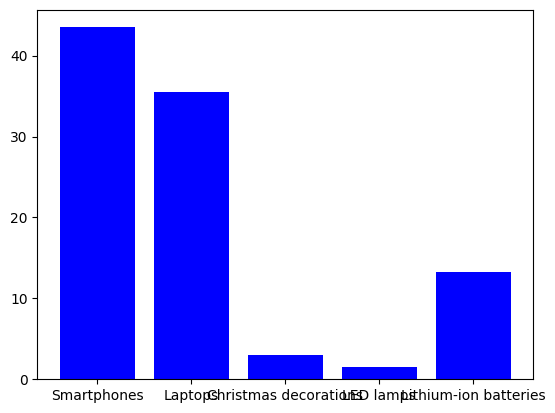

In [11]:
# 不提取列数据的做法
plt.scatter(data["China_exports_in_world_%"],
            data["US_imports_in_world_%"],
            s=data["Trade_value_from_China_to_US_bn"] * 50)
plt.bar(data["Name"], data["Trade_value_from_China_to_US_bn"], color='blue'
)

基础练习里的画图代码

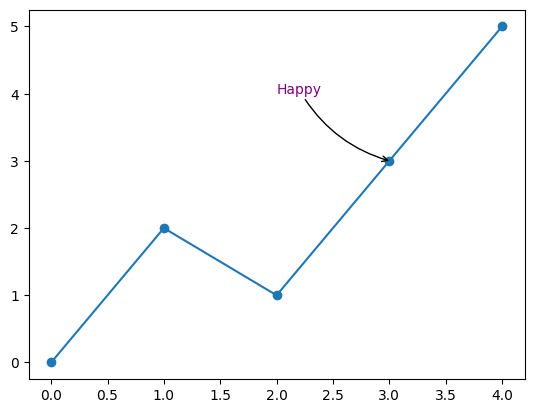

In [14]:
x = [0, 1, 2, 3, 4]
y = [0, 2, 1, 3, 5]
plt.plot(x, y, marker='o')
plt.annotate('Happy',
            xy=(3, 3), # xy 参数指定的是被标注的数据点的位置（箭头指着的地方）
            xytext=(2, 4), 3 xytext 是文字起点的位置
            arrowprops=dict(facecolor='green', arrowstyle='->', shrinkA=0.1, shrinkB=0.1, connectionstyle='arc3 ,rad=0.2'), # shrinkA 和 shrinkB 是让箭头两端稍微缩短一点，不要死死贴着文字和数据点，让图表更美观。
            fontsize=10, color='purple')
plt.show()

Matplotlib配色功能，Matplotlib 的颜色映射模块 Colormap，简称cm

导入模块的三种写法
```python
1. 
from matplotlib import cm
colors = cm.Set3(range(10)) # 直接写 cm.XXX
2. 
import matplotlib.cm
colors = matplotlib.cm.Set3(range(10)) # 必须写全称，否则报错
3. 
import matplotlib.cm as cm
```
以下是 Matplotlib 中一些常用的配色方案：
- Sequential（连续配色方案）：
    - viridis
    - plasma
    - cividis
    - magma
- Diverging（分歧配色方案）：
    - coolwarm
    - Spectral
- Qualitative（离散配色方案）：
    - Set1
    - Set2
    - Set3
    - Dark2
    - Accent

<BarContainer object of 5 artists>

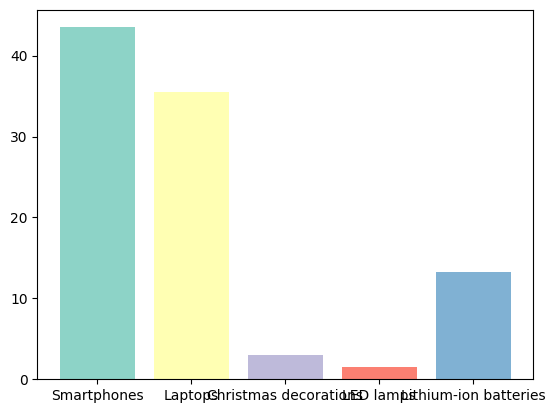

In [15]:
# 导入颜色映射模块
from matplotlib import cm 
# 使用Set3配色方案生成颜色
colors = cm.Set3(range(len(names))) 
# 应用颜色到每个柱子
plt.bar(names , values , color=colors) 

## 复杂练习
1. 从国家统计局网站 https://data.stats.gov.cn/easyquery.htm 中找到“年度数据”-“国民经济核算”-“国民生产总值指数”，下载从 1978 年以来的这个指数。这个指数减去 100 就可以理解为 GDP 增速了。
2. 下载后，不要在excel中对数据做预处理，而是把它导入到 python 中，然后一步一步用 python 来处理。
3. 画图，横轴是年份、纵轴是经济增速，尝试用不同的背景色或者区间或者标注，来说明中国经济增长的不同阶段。这是对逻辑、配色、图表美观、代码能力的多重考验，你可以使用 AI 辅助，只要最后的图美观清晰就好！
4. 可以把分行业的增加值指数一起放进来，看看在不同的阶段，都是哪些行业在驱动经济增长

成功提取到的真实列名：
GDP列: 国内生产总值指数 (上年=100)
第一产业列: 第一产业增加值指数 (上年=100)


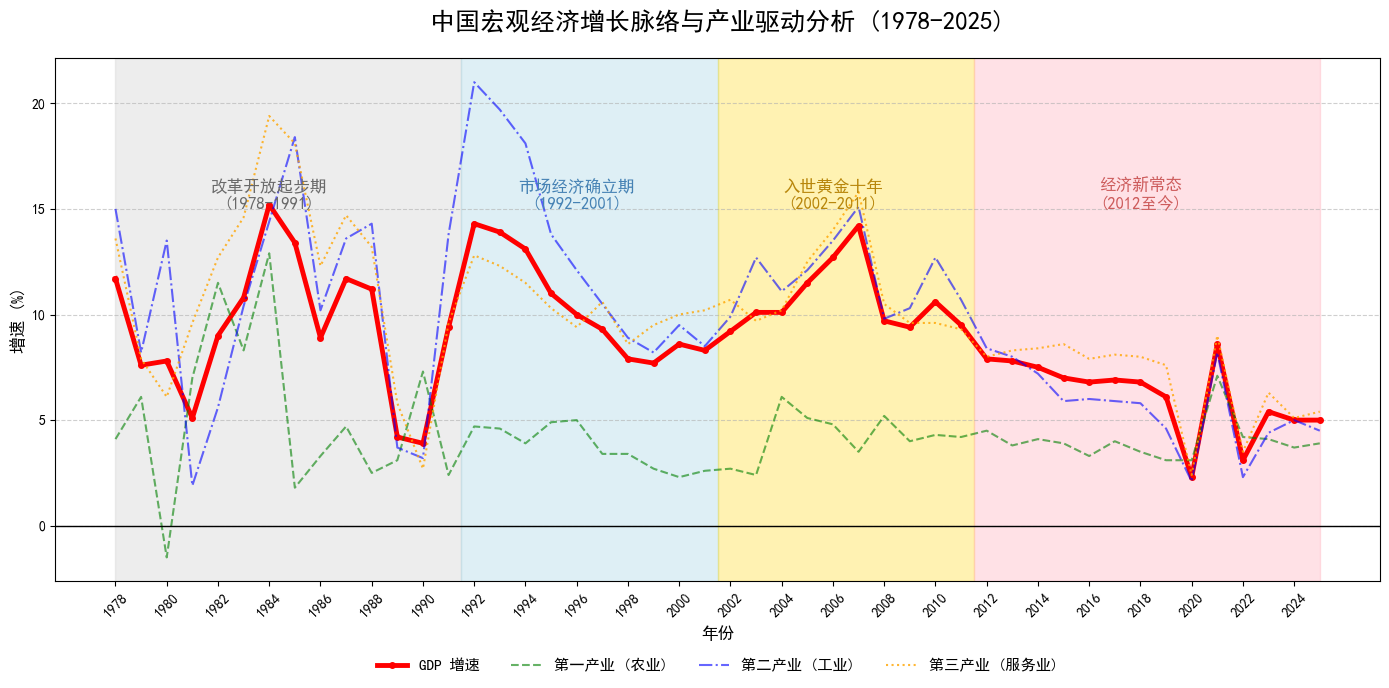

In [20]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# Step 0: 解决 Matplotlib 中文显示乱码的问题
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows 请使用 'SimHei'
plt.rcParams['axes.unicode_minus'] = False    # 正常显示负号
# ==========================================
# Step 1: 读取与清洗数据 
os.chdir(r"D:\jjdsjyrgzn_python\3shangjike")
# 2. 读取数据：
# 我们跳过前2行 (skiprows=2)，并忽略底部无用信息 (skipfooter=2)
df = pd.read_excel("年度数据.xlsx", skiprows=2, skipfooter=2)
# 3. 数据清洗
# 把“指标”这一列设置为索引，方便后续提取
df.set_index('指标', inplace=True)
df.index = df.index.str.strip() # 去除前后空格
df.index = df.index.str.replace('（', '(').str.replace('）', ')') # 把中文括号替换为英文括号
# 此时年份是列名，为了画图需要把表格转置一下，让年份变成索引
df = df.T
# 清洗年份：现在的索引是 "2025年", "2024年"，我们需要去掉"年"字，变成数字，并按时间从小到大排序
df.index = df.index.str.replace('年', '').astype(int)
df.sort_index(inplace=True)
# 4. 计算增速
df_growth = df - 100
# 只要列名中包含关键词，就自动抓取那一列的第一项 [0]
col_gdp =[col for col in df_growth.columns if '国内生产总值' in col][0]
col_pri =[col for col in df_growth.columns if '第一产业' in col][0]
col_sec =[col for col in df_growth.columns if '第二产业' in col][0]
col_ter =[col for col in df_growth.columns if '第三产业' in col][0]
# 打印出来看看 Python 到底抓到了什么鬼名字（你可以观察一下控制台的输出）
print("成功提取到的真实列名：")
print("GDP列:", col_gdp)
print("第一产业列:", col_pri)

# 提取我们要画图的特定列
gdp_growth = df_growth[col_gdp]
primary_ind = df_growth[col_pri]
secondary_ind = df_growth[col_sec]
tertiary_ind = df_growth[col_ter]
# ==========================================
# Step 2: 绘图
fig, ax = plt.subplots(figsize=(14, 7))
# 1. 画折线图：主线（GDP）加粗，三大产业用虚线和较浅颜色作为辅助
ax.plot(gdp_growth.index, gdp_growth, label='GDP 增速', color='red', linewidth=3.5, marker='o', markersize=4)
ax.plot(primary_ind.index, primary_ind, label='第一产业 (农业)', color='green', linestyle='--', alpha=0.6)
ax.plot(secondary_ind.index, secondary_ind, label='第二产业 (工业)', color='blue', linestyle='-.', alpha=0.6)
ax.plot(tertiary_ind.index, tertiary_ind, label='第三产业 (服务业)', color='orange', linestyle=':', alpha=0.8)
# 2. 用背景色划分中国经济发展的不同阶段
# 阶段一：1978 - 1991 (改革开放初期)
ax.axvspan(1978, 1991.5, color='lightgray', alpha=0.4)
plt.text(1984, 15, '改革开放起步期\n(1978-1991)', fontsize=12, color='dimgray', ha='center')
# 阶段二：1992 - 2001 (社会主义市场经济确立，高速发展)
ax.axvspan(1991.5, 2001.5, color='lightblue', alpha=0.4)
plt.text(1996, 15, '市场经济确立期\n(1992-2001)', fontsize=12, color='steelblue', ha='center')
# 阶段三：2002 - 2011 (加入WTO，黄金十年)
ax.axvspan(2001.5, 2011.5, color='gold', alpha=0.3)
plt.text(2006, 15, '入世黄金十年\n(2002-2011)', fontsize=12, color='darkgoldenrod', ha='center')
# 阶段四：2012 - 2025 (经济新常态)
ax.axvspan(2011.5, 2025, color='lightpink', alpha=0.4)
plt.text(2018, 15, '经济新常态\n(2012至今)', fontsize=12, color='indianred', ha='center')
# 3. 细节美化
ax.set_title('中国宏观经济增长脉络与产业驱动分析 (1978-2025)', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('年份', fontsize=12)
ax.set_ylabel('增速 (%)', fontsize=12)
# 添加一条表示“0%增速”的水平警戒线
ax.axhline(0, color='black', linewidth=1) 
# 设置X轴的刻度间隔（每2年显示一次，防止文字挤在一起）
plt.xticks(range(1978, 2026, 2), rotation=45)
# 添加网格线
ax.grid(axis='y', linestyle='--', alpha=0.6)
# 将图例放在图表下方
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4, fontsize=11, frameon=False)
# 自动调整布局防遮挡
plt.tight_layout()
# 展示图表
plt.show()